# Exercise 5: Adversarial Attacks III

**Group Members (please state here)**:
1.   Avik Das
2.   Student 2
3.   Student 3

**Please submit as groups of no more than three students.**

---

This exercise will help you explore and understand how to use the principle of the DeepFool attack on a neural network as a metric of evaluating robustness. You will implement a convolutional neural network and train it on a dataset before and multiple times after the dataset was augmented with different levels of noise. At last, you will use the DeepFool attack from exercise 3 as a tool to evaluate each models robustness with respect to the varying levels of noise augmentation introduced to the data before the training process.

<br>

## Deliverables

**Task 1**: Implementation and training of a convolutional neural network

**Task 2**: Evaluation of the networks robustness


<br>

**End your notebook with a brief report documenting your findings, experiments and observations.**

## 0 - Imports

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## 1 - Convolutional Neural Network Classifier

### 1a - Implementation

#### Instructions
- Implement a convolutional neural network (CNN) with an architecture of your choice to perform classification on image data
- Use the FMNIST dataset
- Split the FMNIST dataset into 3 smaller distinct sets, s.t. 5000 samples are used for training, 200 samples are used for validation during training and 100 samples are used in task 2 during the evaluation

In [13]:
# Load FMNIST dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test_full  = x_test_full.astype("float32") / 255.0

# Add channel dimension (1 color channel - grayscale)
x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test_full  = np.expand_dims(x_test_full, axis=-1)
### -1 means: add it at the end ###

In [14]:
# Create required splits

np.random.seed(42)

# Shuffle training data first
indices = np.random.permutation(len(x_train_full))
x_train_full = x_train_full[indices]
y_train_full = y_train_full[indices]

# 5000 training samples (0 to 4999)
x_train = x_train_full[:5000]
y_train = y_train_full[:5000]

# 200 validation samples (5000 to 5199)
x_val = x_train_full[5000:5200]
y_val = y_train_full[5000:5200]

# 100 samples for DeepFool evaluation (0 to 99)
x_test = x_test_full[:100]
y_test = y_test_full[:100]

print("Train set:", x_train.shape, y_train.shape)
print("Val set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

Train set: (5000, 28, 28, 1) (5000,)
Val set: (200, 28, 28, 1) (200,)
Test set: (100, 28, 28, 1) (100,)


In [15]:
# Define CNN architecture

def create_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
        tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Dropout(0.25),
    
        tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
        tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Dropout(0.25),
    
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
    
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [16]:
cnn_model = create_cnn()

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,482 (771.41 KB)

 Trainable params: 197,482 (771.41 KB)

 Non-trainable params: 0 (0.00 B)

### 1b - Data Augmentation

#### Instructions
- For 1c, implement a method that augments the data by adding noise with specified standard deviation to each batch during training.
- For the augmentation use gaussian noise $N(0, \sigma^2)$ with variances $\sigma$: 1e-3, 1e-2, 1e-1 and 1


In [17]:
# images are normalized to [0,1]. That means most pixel values are somewhere between 0 (black) and 1 (white). 
# Now Gaussian noise is additive, so you are literally doing:
# x′= x + ϵ , where, ϵ∼N(0,σ^2)
# So the size of σ determines how violently you disturb each pixel.

# Why σ = 0.001 is almost invisible
# With σ = 0.001, most noise values are extremely tiny:
# typical noise might be around ±0.001
# that’s 0.1% of the full intensity range

# Why σ = 0.01 is still mild
# Now noise is around ±0.01:
# still small compared to [0,1]

# Why σ = 0.1 becomes noticeable
# Now it gets serious:
# noise can be ±0.1, that’s 10% of full intensity range
# So pixels start shifting enough to:
# blur edges, introduce grain, slightly distort shapes
# But the object is still recognizable.

# Why σ = 1.0 is extreme
# This is the key intuition:
# noise is now ±1.0 scale
# that is the same magnitude as the entire pixel range

# low σ → model learns small robustness
# high σ → model is forced to learn very stable features
# too high σ → data becomes unrealistic, accuracy drops

# https://www.datacamp.com/doc/numpy/random-normal

In [18]:
def add_gaussian_noise(x, sigma):
    """
    Adds Gaussian noise N(0, sigma^2) to images.
    
    Parameters:
        x: input images (numpy array)
        sigma: standard deviation of noise
    
    Returns:
        noisy images clipped to [0,1]
    """
    noise = np.random.normal(loc=0.0, scale=sigma, size=x.shape)
    x_noisy = x + noise
    return np.clip(x_noisy, 0.0, 1.0) # same magnitude as the entire pixel range

In [19]:
# indices = np.random.permutation(n_samples)

# Suppose you have 5000 training images.
# Without this line, the batches would always be:

# Batch 1: images 0-31
# Batch 2: images 32-63
# ...

# for every epoch.
# With this line,

# indices = np.random.permutation(n_samples)

# the order is randomly shuffled each epoch:

# Epoch 1:
# Batch 1: [415, 12, 2800, ...]
# Epoch 2:
# Batch 1: [95, 4820, 33, ...]
# Epoch 3:
# Batch 1: [1876, 4, 3911, ...]

# Shuffling is standard practice because it prevents the model from always seeing the data in exactly the same order.


In [20]:
def noisy_batch_generator(x, y, batch_size, sigma):

    n_samples = len(x)

    while True:

        # Shuffle data every epoch
        indices = np.random.permutation(n_samples)

        x_shuffled = x[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, batch_size):
            
            # Compute the end index of the current batch
            end = start + batch_size 

            x_batch = x_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Add fresh noise to this batch
            x_batch_noisy = add_gaussian_noise(x_batch, sigma)

            yield x_batch_noisy, y_batch

### 1c - Training

#### Instructions
- Train the convolutional neural network separately once for each of the 5 datasets from 1b
- Use 100 epochs during training
- For each dataset, use the same amount of epochs
- For each dataset, plot the training accuracy vs validation accuracy


In [21]:
class EpochLogger(tf.keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs=None):

        if (epoch + 1) == 1 or (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch+1:3d}/100 - "
                f"accuracy: {logs['accuracy']:.4f} - "
                f"val_accuracy: {logs['val_accuracy']:.4f}"
            )

In [22]:
noise_levels = [0, 1e-3, 1e-2, 1e-1, 1]

batch_size = 32

models = {}
histories = {}

for sigma in noise_levels:

    print(f"\nTraining model with sigma = {sigma}")

    # Create a new CNN
    model = create_cnn()

    if sigma == 0:

        # Baseline model (no augmentation)
        history = model.fit(
            x_train,
            y_train,
            epochs=100,
            batch_size=batch_size,
            validation_data=(x_val, y_val),
            verbose=0,
            callbacks=[EpochLogger()]
        )

    else:

        train_generator = noisy_batch_generator(
            x_train,
            y_train,
            batch_size=batch_size,
            sigma=sigma
        )

        history = model.fit(
            train_generator,
            steps_per_epoch=len(x_train) // batch_size, # 5000 // 32 = 156
            # During each epoch, the model will train on 156 batches
            epochs=100,
            validation_data=(x_val, y_val),
            verbose=0,
            callbacks=[EpochLogger()]
        )

    models[sigma] = model
    histories[sigma] = history


Training model with sigma = 0
Epoch   1/100 - accuracy: 0.5342 - val_accuracy: 0.7300
Epoch  10/100 - accuracy: 0.8454 - val_accuracy: 0.8300
Epoch  20/100 - accuracy: 0.8950 - val_accuracy: 0.8450
Epoch  30/100 - accuracy: 0.9150 - val_accuracy: 0.8700
Epoch  40/100 - accuracy: 0.9430 - val_accuracy: 0.8800
Epoch  50/100 - accuracy: 0.9492 - val_accuracy: 0.8700
Epoch  60/100 - accuracy: 0.9582 - val_accuracy: 0.8950
Epoch  70/100 - accuracy: 0.9638 - val_accuracy: 0.8750
Epoch  80/100 - accuracy: 0.9756 - val_accuracy: 0.8700
Epoch  90/100 - accuracy: 0.9732 - val_accuracy: 0.8800
Epoch 100/100 - accuracy: 0.9774 - val_accuracy: 0.8850

Training model with sigma = 0.001
Epoch   1/100 - accuracy: 0.5487 - val_accuracy: 0.7350
Epoch  10/100 - accuracy: 0.8514 - val_accuracy: 0.8500
Epoch  20/100 - accuracy: 0.8923 - val_accuracy: 0.9000
Epoch  30/100 - accuracy: 0.9281 - val_accuracy: 0.8750
Epoch  40/100 - accuracy: 0.9442 - val_accuracy: 0.8700
Epoch  50/100 - accuracy: 0.9515 - val

In [23]:
# accuracy_results = {}

# for sigma in noise_levels:

#     acc = histories[sigma].history["val_accuracy"][-1]
#     accuracy_results[sigma] = acc

# print(accuracy_results)

In [32]:
train_accuracy_results = {}

for sigma in noise_levels:

    train_acc = histories[sigma].history["accuracy"]

    train_accuracy_results[sigma] = np.mean(train_acc[-10:])

print(train_accuracy_results)

{0: np.float64(0.9746400058269501), 0.001: np.float64(0.975281810760498), 0.01: np.float64(0.9728864669799805), 0.1: np.float64(0.9403985559940338), 1: np.float64(0.6630032241344452)}


In [24]:
accuracy_results = {}

for sigma in noise_levels:

    val_acc = histories[sigma].history["val_accuracy"]

    accuracy_results[sigma] = np.mean(val_acc[-10:])

print(accuracy_results)

{0: np.float64(0.8730000019073486), 0.001: np.float64(0.8810000002384186), 0.01: np.float64(0.8829999923706054), 0.1: np.float64(0.8620000064373017), 1: np.float64(0.7574999868869782)}


In [34]:
overfitting_gap = {}

for sigma in noise_levels:

    overfitting_gap[sigma] = (
        train_accuracy_results[sigma]
        - accuracy_results[sigma]
    )

print(overfitting_gap)

{0: np.float64(0.10164000391960148), 0.001: np.float64(0.0942818105220794), 0.01: np.float64(0.08988647460937504), 0.1: np.float64(0.07839854955673209), 1: np.float64(-0.09449676275253294)}


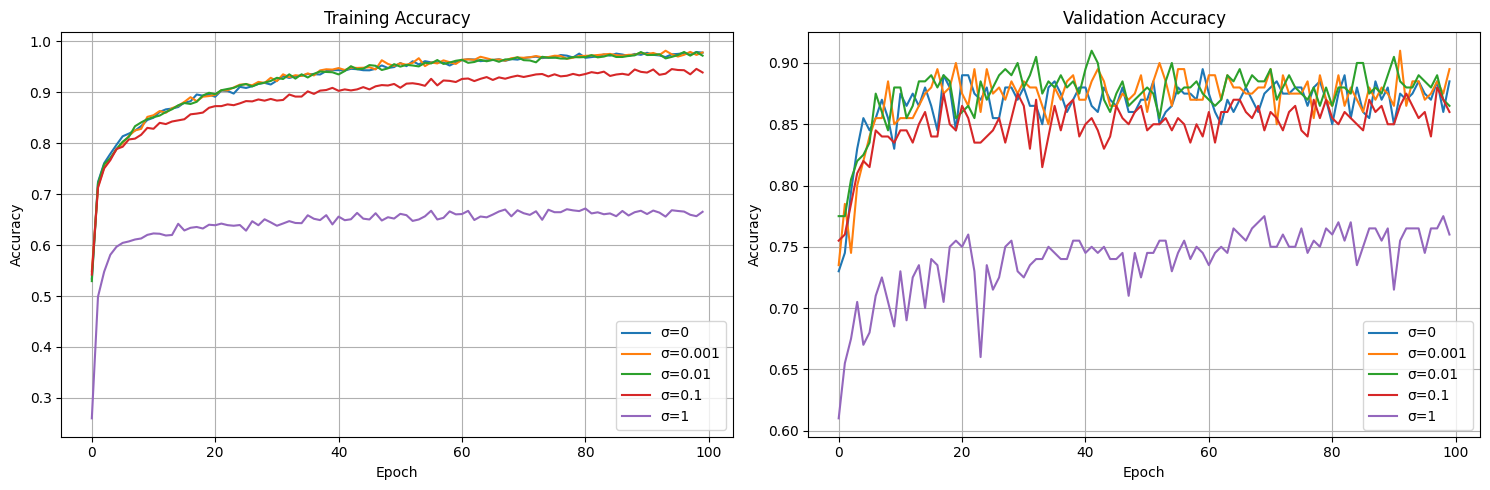

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training accuracy
for sigma in noise_levels:
    axes[0].plot(
        histories[sigma].history['accuracy'],
        label=f'σ={sigma}'
    )

axes[0].set_title("Training Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid()
axes[0].legend()

# Validation accuracy
for sigma in noise_levels:
    axes[1].plot(
        histories[sigma].history['val_accuracy'],
        label=f'σ={sigma}'
    )

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

- Yes, overfitting is visible in the graphs. In most of the models the training accuracy is higher than the validation accuracy, especially after some epochs. This gap between training and validation accuracy shows that the model is learning the training data better than the unseen validation data, which is a sign of overfitting. It is more clear in the case where there is no noise or very small noise.

- Augmentation with noise affects the magnitude of overfitting. For low and medium noise levels (sigma = 0.001, 0.01 and 0.1), the effect is moderate and the models still exhibit overfitting. For very high noise level (sigma = 1), the model begins to underfit, since the training accuracy becomes lower than the validation accuracy.

- The augmentation with noise does impact the validation accuracy. Small amounts of noise, especially sigma = 0.001 and sigma = 0.01, slightly improve the validation accuracy compared to training without noise. However, larger noise levels reduce the validation accuracy because the images become too corrupted and the model cannot learn useful patterns well.

## 2 - Evaluation

- Use the principle of the DeepFool adversarial attack on each of your 5 trained CNN classifiers from task 1 and evaluate your results

### 2a - DeepFool (2016)

#### Instructions

- Evaluate the robustness to adversarial perturbations of each of the 5 trained models from task 1
- Therefore, compute the average robustness $\hat{\rho}_{\text{adv}}(f)$ as defined in equation 15 of the [DeepFool](https://arxiv.org/pdf/1511.04599) paper: $\hat{\rho}_{\text{adv}}(f)=\frac{1}{|\mathscr{D}|} \sum_{x\in\mathscr{D}}\frac{\| \hat{r} (x) \|_2 }{\|x\|_2}$

In [26]:
# from last assignment
def attack_deepfool(model, x, num_classes=10, max_iter=50, overshoot=0.02):

    x_adv              = x.copy()
    total_perturbation = np.zeros_like(x)

    # Get original class from full model call
    x_var      = tf.Variable(x_adv[np.newaxis], dtype=tf.float32)
    orig_probs = model(x_var, training=False).numpy()[0]
    orig_class = int(np.argmax(orig_probs))

    for i in range(max_iter):

        x_var = tf.Variable(x_adv[np.newaxis], dtype=tf.float32)

        # Compute per-class gradients via individual tape calls
        grads = []
        current_probs = None
        for k in range(num_classes):
            with tf.GradientTape() as tape:
                tape.watch(x_var)
                probs = model(x_var, training=False)   # (1, 10)
                score_k = probs[0, k]
            g = tape.gradient(score_k, x_var)
            grads.append(g.numpy()[0])
            if k == 0:
                current_probs = probs.numpy()[0]

        current_class = int(np.argmax(current_probs))
        if current_class != orig_class:
            break

        grad_orig  = grads[orig_class]
        min_dist   = np.inf
        best_delta = None

        for k in range(num_classes):
            if k == orig_class:
                continue

            w_k    = grads[k] - grad_orig
            f_k    = float(current_probs[k] - current_probs[orig_class])
            norm_w = np.linalg.norm(w_k.flatten()) + 1e-8
            dist_k = abs(f_k) / norm_w

            if dist_k < min_dist:
                min_dist   = dist_k
                best_delta = (abs(f_k) / (norm_w ** 2)) * w_k

        if best_delta is None:
            break

        total_perturbation += (1 + overshoot) * best_delta
        x_adv = np.clip(x + total_perturbation, 0.0, 1.0)

    perturbation = x_adv - x
    final_pred   = model(tf.constant(x_adv[np.newaxis], dtype=tf.float32),
                         training=False).numpy()[0]
    final_class  = np.argmax(final_pred)

    return x_adv, perturbation, orig_class, final_class, final_pred, i + 1

In [27]:
def compute_robustness(model, x_data):

    epsilons = []

    for i in range(len(x_data)):

        x = x_data[i]

        # run DeepFool
        adv_x, perturbation, _, _, _, _ = attack_deepfool(
            model=model,
            x=x,
            num_classes=10,
            max_iter=50,
            overshoot=0.02
        )

        # compute L2 norms
        r_norm = np.linalg.norm(perturbation)
        x_norm = np.linalg.norm(x) + 1e-8  # avoid division by zero

        eps = r_norm / x_norm
        epsilons.append(eps)

    return np.mean(epsilons)

In [28]:
# r_norm computes: ∥r(x)∥_2

# Meaning:
# How big is the adversarial change?

# If perturbation is small → attack is strong (model is fragile)
# If perturbation is large → model is robust


# x_norm computes: ∥x∥_2

# Meaning:
# How big is the original image in total energy (pixel magnitude)
# The + 1e-8 is just safety to avoid division by zero (very rare but good practice).


# eps = r_norm / x_norm -> We compare perturbation size relative to image size (normalization perturbation).

# np.mean(epsilons) gives: ρ_adv(f)
# Meaning: average robustness of the model over the dataset
# | Model type   | ρ_adv |
# | ------------ | ----- |
# | weak model   | small |
# | strong model | large |


In [29]:
print(models.keys())

dict_keys([0, 0.001, 0.01, 0.1, 1])


In [30]:
robustness_results = {}

for sigma, model in models.items():

    print(f"Evaluating robustness for sigma = {sigma}")

    rho = compute_robustness(model, x_test)
    robustness_results[sigma] = rho

    print(f"Robustness: {rho:.6f}")

Evaluating robustness for sigma = 0
Robustness: 1.046767
Evaluating robustness for sigma = 0.001
Robustness: 1.099355
Evaluating robustness for sigma = 0.01
Robustness: 0.995727
Evaluating robustness for sigma = 0.1
Robustness: 1.008413
Evaluating robustness for sigma = 1
Robustness: 0.570956


### 2b - Visualization

#### Instructions
- Visualize your results by plotting both noise $N(\mu, \sigma^2)$ vs average robustness $\hat{\rho}_{\text{adv}}(f)$ as well as noise $N(\mu, \sigma^2)$ vs accuracy in a single plot

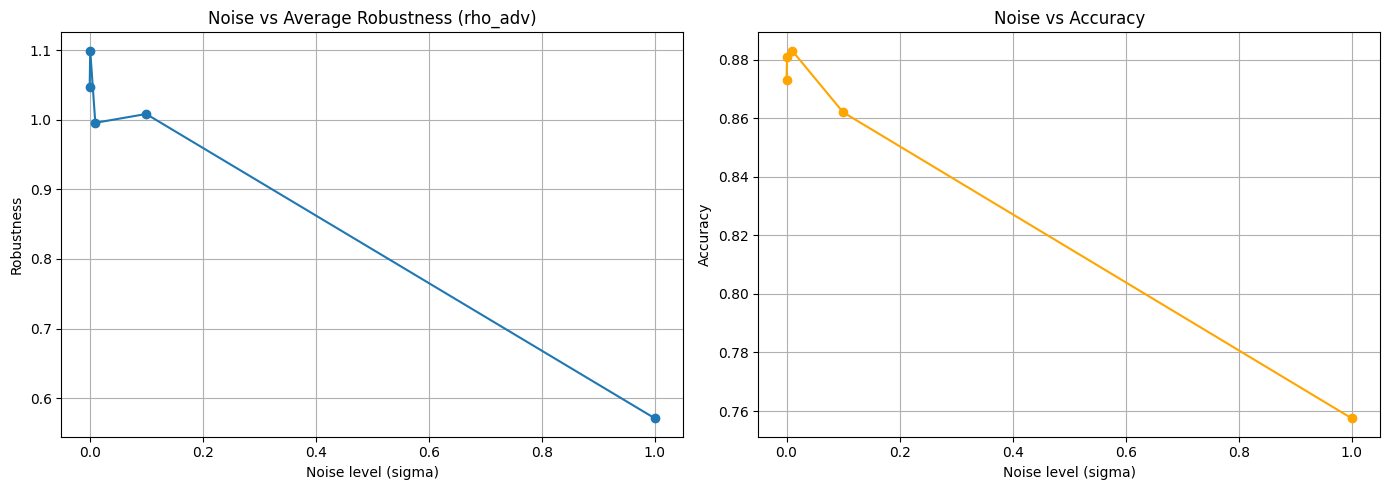

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Noise vs Robustness ---
axes[0].plot(
    list(robustness_results.keys()),
    list(robustness_results.values()),
    marker='o'
)

axes[0].set_title("Noise vs Average Robustness (rho_adv)")
axes[0].set_xlabel("Noise level (sigma)")
axes[0].set_ylabel("Robustness")
axes[0].grid()

# --- Plot 2: Noise vs Accuracy ---
axes[1].plot(
    list(accuracy_results.keys()),
    list(accuracy_results.values()),
    marker='o',
    color='orange'
)

axes[1].set_title("Noise vs Accuracy")
axes[1].set_xlabel("Noise level (sigma)")
axes[1].set_ylabel("Accuracy")
axes[1].grid()

plt.tight_layout()
plt.show()

### 2c - Questions

Answer the following questions:

- Did the training with augmented data result in more robustness of the CNN classifier?
- How is the robustness correlated to the noise level?
- Is there a sweetspot for the noise vs accuracy trade-off?

- Yes, training with augmented data resulted in a small improvement in robustness, but only for low noise levels. Compared to the model trained without noise, the model trained with sigma = 0.001 achieved the highest average robustness. However, increasing the noise further did not continuously improve robustness. In particular, the model trained with σ = 1 showed a large decrease in robustness. Therefore, moderate noise augmentation can improve robustness, while excessive noise has a negative effect.

- The robustness is not strongly or linearly correlated with the noise level. The robustness reaches its maximum at sigma = 0.001, decreases slightly at sigma = 0.01, recovers a little at sigma = 0.1, and then drops significantly at sigma = 1. This shows that increasing the noise level does not always increase robustness. Instead, the relationship is non-linear, and very large amounts of noise reduce the robustness of the classifier.

- There appears to be a sweet spot in the trade-off between noise and accuracy. The models trained with sigma = 0.001 and sigma = 0.01 achieved the highest validation accuracies while also maintaining relatively high robustness values. In contrast, the model trained with sigma = 1 had both the lowest accuracy and the lowest robustness. Therefore, small amounts of Gaussian noise provide the best balance between classification performance and adversarial robustness.

In this exercise, a convolutional neural network was trained on the Fashion-MNIST dataset using five different levels of Gaussian noise augmentation. 

The training and validation curves showed that overfitting was present for most models, while very high noise caused underfitting. Small noise levels achieved slightly better validation accuracy compared to training without noise, whereas large noise significantly reduced the performance. 

The robustness of the models was evaluated using the DeepFool attack where most of the works were already done in the last assignment. The results showed that low levels of noise provided a small improvement in robustness, but increasing the noise further did not continuously improve robustness. In particular, excessive noise degraded both robustness and accuracy. Overall, a small amount of Gaussian noise provided the best trade-off between classification accuracy and adversarial robustness.